# KPI 

**Objectives** 

This notebook aims to group LGAs into based on adoption profiles. To this end, key drivers of DER adoption need to be identified and new metrics derived.  

**Key Outputs**

1. Cleaned data for inconsistencies including mismatch between total sums and individual counts of business size and population education level and errors in capacity type in DER data. 
2. Separated data for residential and business data. 
3. For each LGA several key metrics are calculated:
    - Penetration rate: connections per dwelling/business.
    - Capacity per dwelling/business.
    - Annual adoption rate: coefficient of year in linear regression model predicting capacity. 
    - Quality: Capacity per connection.
    - BSR: battery connections to solar connections ratio.

**Data** 

Data is initially taken from three sources (ABS,AEMO and geographical mapping) and processed into three fact tables. Each table is indexed by year and LGA. 
- Q_Main_Derr: Aggregate AEMO DER data by LGA and year then joining LGA via postcode.
- Q_Population_Agg: Population data including population, median age, income, education levels in long form. 
- Q_Business_Agg: Economic data table including counts for business sectors and business size in long form. 
More details can be found in the README.md file. 

In [258]:
import sqlite3 as sql
import pandas as pd

import numpy as np
np.random.seed(42)
np.seterr(divide='ignore', over='ignore', invalid='ignore') # Ignore divide by 0 warnings

from matplotlib import pyplot as plt
import seaborn as sns


In [259]:
#  --- Load datasets from SQLite database --- #

DB_PATH = "../data/sql_db/Energy.db"

conn = sql.connect(DB_PATH)

# Main dataset with Capacity, Number of Connections per Population/Businesses
derr_df = pd.read_sql_query("SELECT * FROM Fact_Derr", conn)

# Auxiliary data set containing demographic and socioeconomic data
population_df = pd.read_sql_query("SELECT * FROM Dim_Population", conn)
economy_df = pd.read_sql_query("SELECT * FROM Dim_Economic", conn)
dwelling_df = pd.read_sql_query("SELECT * FROM Dim_Dwelling", conn)

conn.close()

## Exploratory Data Analysis

 We check the following in the dataset:
 - invalid entries in columns,
 - inconsistent counts in number of total businesses and number for each sector or size grouping,
 - distribution of features and 
 - correlation between columns. 


### Invalid Entries

We first investigate invalid entries in the aggregated AEMO DERR data. 

Checking the NAs shows that LGA column contains five NA rows. 



In [260]:
#  --- Check NaNs --- #
print("NA:Check")
print(" ------- ")
print(derr_df.isna().sum())

NA:Check
 ------- 
Year                   0
Lga                    5
Type                   0
TotalCapacity          0
BatteryCapacity        0
SolarCapacity          0
OtherCapacity          0
TotalDerConnections    0
BatteryConnections     0
SolarConnections       0
OtherConnections       0
dtype: int64


The five rows correspond to aggregate data for NA LGA's over 5 years. With no way to recover these LGA, we propose to remove them in the analysis. 

In [261]:
derr_df[derr_df['Lga'].isna()]

,Year,Lga,Type,TotalCapacity,BatteryCapacity,SolarCapacity,OtherCapacity,TotalDerConnections,BatteryConnections,SolarConnections,OtherConnections
0,2021,NaN,RESIDENTIAL,1663.62,0.0,1663.62,0.0,400.0,0.0,400.0,0.0
1,2022,NaN,RESIDENTIAL,1949.12,64.6,1884.52,0.0,442.0,7.0,435.0,0.0
2,2023,NaN,RESIDENTIAL,2008.00,73.8,1934.20,0.0,450.0,9.0,441.0,0.0
3,2024,NaN,RESIDENTIAL,1580.80,69.2,1511.60,0.0,337.0,8.0,329.0,0.0
4,2025,NaN,RESIDENTIAL,322.00,40.0,282.00,0.0,80.0,4.0,76.0,0.0


The type column contains entries such as 'blank' and 'NoClassification'. Printing out LGAs with these rows indicates that LGAs and years with (blank) all contain 'RESIDENTIAL' and "BUSINESS' types. This is confirmed by checking the proportion of these entries.


In [262]:
# --- LGAs with 'Blank' in Type Column --- #

problem_lga_year = derr_df[derr_df['Type']=='(blank)']
derr_blank_df = derr_df.merge(problem_lga_year[['Lga','Year']], on=['Lga','Year']).sort_values(['Lga','Year'])

# Print out rows with type entry '(blank)'
print(derr_blank_df.head(6))

# Confirm that all LGAs with (blank) also contains BUSINESS and RESIDENTIAL entries 
three_entries = np.mean(derr_blank_df.groupby(['Lga','Year']).count()['Type'].values == 3)
print("Number of LGA with three type entries: " + str(three_entries))


   Year      Lga         Type  TotalCapacity  BatteryCapacity  SolarCapacity  \
0  2025  10470.0      (blank)        201.200           26.000        175.200   
1  2025  10470.0     BUSINESS      41510.640          236.600      41274.240   
2  2025  10470.0  RESIDENTIAL     219903.410        13600.798     206302.012   
3  2023  10750.0      (blank)        429.800            0.000        429.800   
4  2023  10750.0     BUSINESS     139133.260            0.000     137136.660   
5  2023  10750.0  RESIDENTIAL    1383786.248           20.000    1383373.248   

   OtherCapacity  TotalDerConnections  BatteryConnections  SolarConnections  \
0            0.0                 20.0                 2.0              20.0   
1            0.0               2298.0                28.0            2298.0   
2            0.0              41160.0              1764.0           40736.0   
3            0.0                 52.0                 0.0              52.0   
4         1996.6               7598.0       

Rows with type 'NoClassification' do not appear with counterpart 'RESIDENTIAL' and 'BUSINESS' entries. 

In [263]:
# --- LGAs with 'NoClassification' in Type Column --- #

problem_lga_year = derr_df[derr_df['Type']=='NoClassification']
derr_nc_df = derr_df.merge(problem_lga_year[['Lga','Year']], on=['Lga','Year']).sort_values(by = ['Lga','Year'])

# Print out rows with type entry 'NoCLassification'
print(derr_nc_df.head(6))

   Year      Lga              Type  TotalCapacity  BatteryCapacity  \
0  2021  50080.0  NoClassification        20453.2            161.2   
1  2021  50210.0  NoClassification       336713.8           1139.4   
2  2021  50280.0  NoClassification        39013.3            512.1   
3  2021  50350.0  NoClassification       122810.5            312.2   
4  2021  50420.0  NoClassification       119388.1            483.7   
5  2021  50490.0  NoClassification       134820.3            437.1   

   SolarCapacity  OtherCapacity  TotalDerConnections  BatteryConnections  \
0        18812.6         1479.5               5849.0                28.0   
1       327157.9         8416.4              52032.0               277.0   
2        36436.9         2064.0               6978.0               109.0   
3       114393.8         8104.5              14432.0                64.0   
4       114600.2         4304.2              17808.0                99.0   
5       122279.9        12103.2              18071.0 

Next we check the invalid entries in the population dataframe. The number of NA entries for several columns is around 2100. 

In [264]:
#  --- Check NAs --- #
print("NA:Check")
print(" ------- ")
print(population_df.isna().sum())


NA:Check
 ------- 
Lga                                    0
Year                                   0
TotalPopulation                        0
PopulationDensity                    206
MedianAge                              0
MedianEquivalisedHouseholdIncome    2188
Certificate                         2189
AdvDiploma                          2189
BachelorDegree                      2189
GraduateDiploma                     2207
Postgraduate                        2207
dtype: int64


These NAs arise out of the source data bing census data and therefore only collected every four years. We confirm this by checking the dataframe for any given LGA. 

In [265]:
# --- NAs in Population Data --- #
index = population_df['Lga']==10050
population_df.loc[index]

,Lga,Year,TotalPopulation,PopulationDensity,MedianAge,MedianEquivalisedHouseholdIncome,Certificate,AdvDiploma,BachelorDegree,GraduateDiploma,Postgraduate
0,10050,2020,55466.0,181.5,38.5,NaN,NaN,NaN,NaN,NaN,NaN
1,10050,2021,56067.0,183.4,39.1,947.0,24.0,9.2,13.1,2.4,3.7
2,10050,2022,56665.0,185.4,39.2,NaN,NaN,NaN,NaN,NaN,NaN
3,10050,2023,57509.0,188.2,39.3,NaN,NaN,NaN,NaN,NaN,NaN
4,10050,2024,58317.0,190.8,39.3,NaN,NaN,NaN,NaN,NaN,NaN


Finally, we check the invalid entries in businesses data. Below, we detect no NAs entries in any columns of the dataframe.

In [266]:
#  --- Check NaNs --- #
print("NA:Check")
print(" ------- ")
print(economy_df.isna().sum())


NA:Check
 ------- 
Lga                   0
Year                  0
TotalBusinesses       0
PrimaryIndustry       0
SecondaryIndustry     0
TertiaryIndustry      0
QuaternaryIndustry    0
SmallBusinesses       0
MediumBusinesses      0
LargeBusinesses       0
dtype: int64


We need to check that the total business counts are consistent with the business counts within each group (both sector and business size). Here, we plot a histogram of the difference between the sum of businesses in each sector and the total reported number of businesses. We also plot the error margin equal to 0.05 of the total number of business counts. 

Index(['PrimaryIndustry', 'SecondaryIndustry', 'TertiaryIndustry',
       'QuaternaryIndustry'],
      dtype='str')
0.9074954296160878


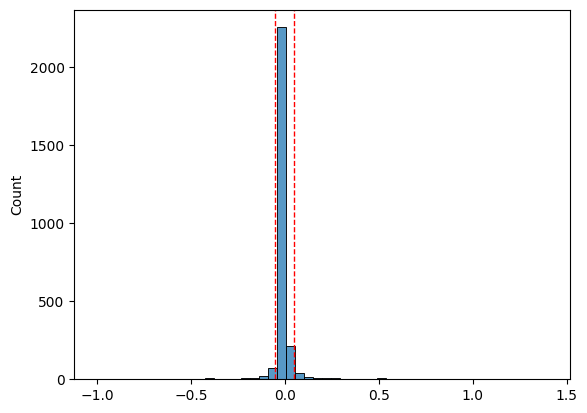

In [267]:
# --- Sector Counts --- #
threshold = 0.05

print(economy_df.columns[3:7])

# Look for mismatches in business sectors data total and sum of sectors
businesss_count = economy_df[economy_df.columns[3:7]].sum(axis=1)
businesss_total = economy_df['TotalBusinesses']
sector_discrepency = (businesss_count-businesss_total)/businesss_total

print((abs(sector_discrepency)<0.05).mean())

sns.histplot(sector_discrepency,bins=50)
plt.axvline(x=threshold, color='red', linestyle='--', linewidth=1, label='Threshold = 0.05')
plt.axvline(x=-threshold, color='red', linestyle='--', linewidth=1, label='Threshold = 0.05')
plt.show()


The plot histogram shows most of the discrepancies are below the threshold. To ensure that there are no obvious outlier points, we plot the sum of businesses in each sector against the total reported umber of businesses as well as a red line indicating equality. 

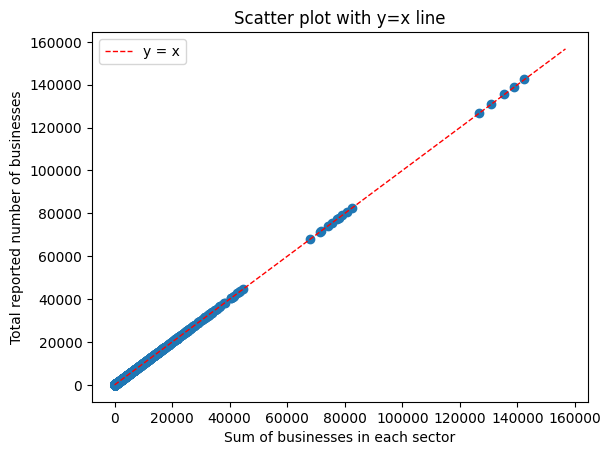

In [268]:
plt.scatter(x=businesss_count,y=businesss_total)

lims = [min(businesss_count), max(businesss_count*1.1)]  # adjust based on your data range
plt.plot(lims, lims, color='red', linestyle='--', linewidth=1, label='y = x')

plt.xlabel('Sum of businesses in each sector')
plt.ylabel('Total reported number of businesses')
plt.title('Scatter plot with y=x line')
plt.legend()
plt.show()

The plot above shows that most points lie close to the line and no outliers are present. 

Similar to the above, we again plot a histogram of the difference between the sum of businesses in each size group and the total reported number of businesses.

Index(['SmallBusinesses', 'MediumBusinesses', 'LargeBusinesses'], dtype='str')
0.9297989031078611


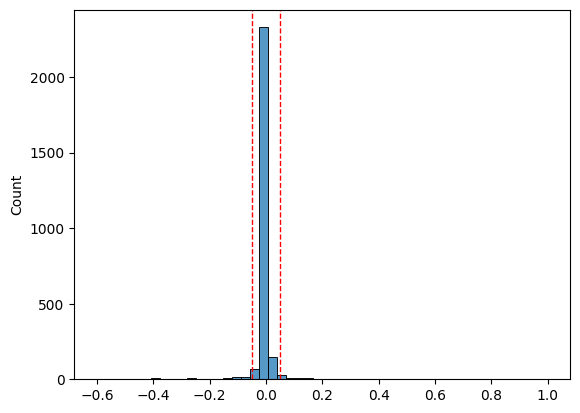

In [269]:
# --- Size Counts --- #

# Columns 
print(economy_df.columns[7:])

# Look for mismatches in business size data total and sum of sizes
businesss_count = economy_df[economy_df.columns[7:]].sum(axis=1)
businesss_total = economy_df['TotalBusinesses']
size_discrepency = (businesss_count-businesss_total)/businesss_total

print((abs(size_discrepency)<0.05).mean())

sns.histplot(size_discrepency,bins=50)
plt.axvline(x=threshold, color='red', linestyle='--', linewidth=1, label='Threshold = 0.05')
plt.axvline(x=-threshold, color='red', linestyle='--', linewidth=1, label='Threshold = 0.05')
plt.show()

Again, most differences lie within the 0.05 error threshold. Next we plot these values as a scatter plot to detect outliers.  

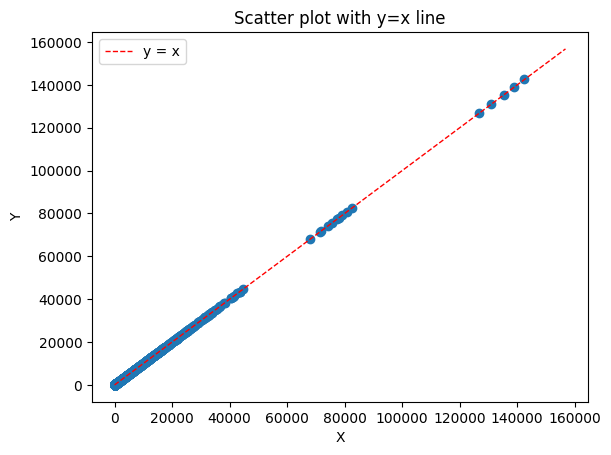

In [270]:
plt.scatter(x=businesss_count,y=businesss_total)

lims = [min(businesss_count), max(businesss_count*1.1)]  # adjust based on your data range
plt.plot(lims, lims, color='red', linestyle='--', linewidth=1, label='y = x')

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Scatter plot with y=x line')
plt.legend()
plt.show()

Again, no outliers are present. 

The process both sector and business size discrepancies we apply the following rule.
- If discrepancy is less than or equal to 5% of total business number, fill NAs with 0.
-  If the discrepancy is larger than 5% the remaining rows, drop LGA. 

Next we investigate invalid entries in dwellings data. 


In [271]:
# Count NAs in columns
dwelling_df.isna().sum()


Lga              0
Year             0
TotalDwelling    0
dtype: int64

There are No NAs in the dwelling data. 

Finally, we look at LGA count consistancy across all data sets. 

In [272]:

# Compare number of LGAs from dwellings data with population data 
lga_counts = {
    'LGA Dwellings': abs(len(dwelling_df)), 
    'LGA Population': len(population_df['Lga'].unique()),
    'LGA Economic': len(economy_df['Lga'].unique())
}
print(lga_counts)

{'LGA Dwellings': 556, 'LGA Population': 547, 'LGA Economic': 547}


Dwelling data contains 9 LGAs more than the economic and population data. Future joins will create NAs.

### Distributions 

Here, the distribution of each column is checked. 

At this point, the dataset is separated into residential data and business data.
- The residential data denoted by `res_df` comprises of DERR data with 'type' being residential and ABS population data, both aggregated by year and LGA. 
- The business data `bus_df` comprises of DERR data with 'type' being business and ABS economic data, both aggregated by year and LGA. 



In [273]:
# --- Create separate business and residential datasets --- #
res_df = derr_df[derr_df['Type']=="RESIDENTIAL"].drop(labels=['Type'], axis=1)
bus_df = derr_df[derr_df['Type']=="BUSINESS"].drop(labels='Type', axis=1)

# Combine residential derr data with ABS population data 
res_df = res_df.merge(
    right=population_df,
    how = 'left',
    on = ['Year','Lga']
    )

# Combine with dwellings data
res_df = res_df.merge(
    right = dwelling_df,
    how = 'left',
    on = ['Year','Lga']
)

# Combine business Derr data with ABS economic data 
bus_df = bus_df.merge(
    right=economy_df,
    how = 'left',
    on = ['Year','Lga']
)


In [274]:
res_df

,Year,Lga,TotalCapacity,BatteryCapacity,SolarCapacity,OtherCapacity,TotalDerConnections,BatteryConnections,SolarConnections,OtherConnections,TotalPopulation,PopulationDensity,MedianAge,MedianEquivalisedHouseholdIncome,Certificate,AdvDiploma,BachelorDegree,GraduateDiploma,Postgraduate,TotalDwelling
0,2021,NaN,1663.620,0.0,1663.620,0.0,400.0,0.0,400.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022,NaN,1949.120,64.6,1884.520,0.0,442.0,7.0,435.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2023,NaN,2008.000,73.8,1934.200,0.0,450.0,9.0,441.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2024,NaN,1580.800,69.2,1511.600,0.0,337.0,8.0,329.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025,NaN,322.000,40.0,282.000,0.0,80.0,4.0,76.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1901,2021,99399.0,123239.520,0.0,123161.520,78.0,24850.0,0.0,24844.0,6.0,2530.0,23.9,49.3,852.0,23.2,9.3,11.0,1.6,3.2,1179.0
1902,2022,99399.0,127960.240,0.0,127882.240,78.0,25408.0,0.0,25402.0,6.0,2518.0,23.8,49.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1903,2023,99399.0,132441.840,0.0,132363.840,78.0,25924.0,0.0,25918.0,6.0,2511.0,23.7,50.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1904,2024,99399.0,145505.280,0.0,145427.280,78.0,27394.0,0.0,27388.0,6.0,2504.0,23.6,51.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN


The distribution of columns from the residential data is shown below where we observe:
- heavily skewed capacity and number of connections,
- heavily skewed total population and population density, 
- median income and age are a slightly skewed normally distributed. 

This indicates that a transformation may need to be utilised for most columns. 

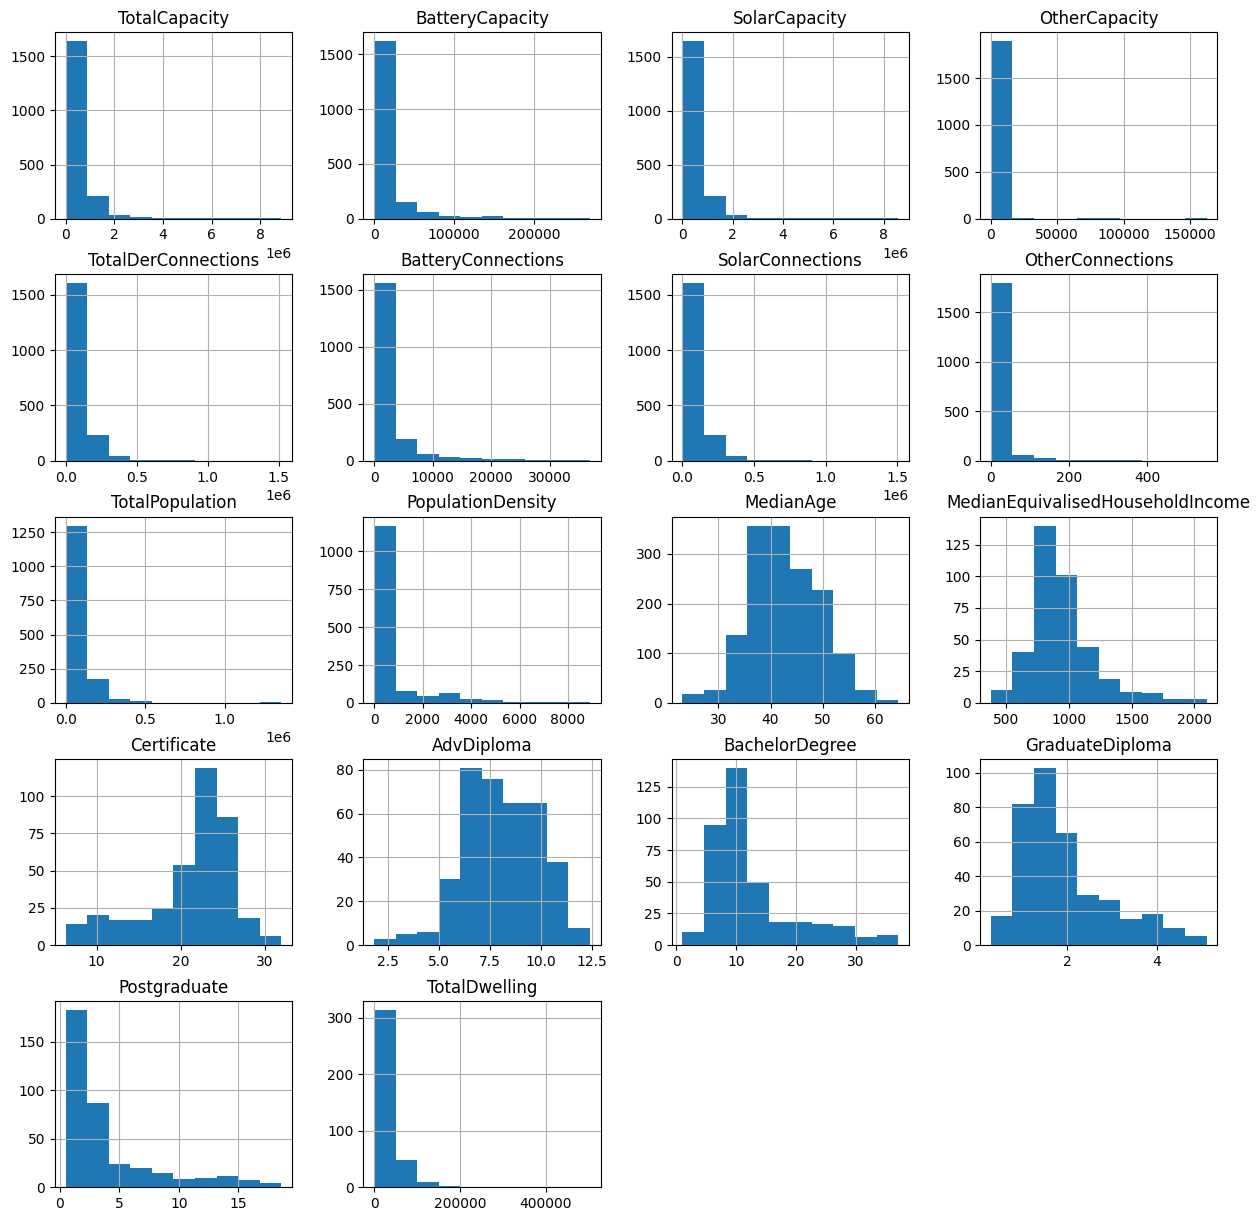

In [275]:
# Plot histogram of residential dataset
_ = res_df.drop(['Lga','Year'],axis=1).hist(figsize=(15,15))
plt.show()

The distribution of columns from the business data is shown below. 

The distribution of columns from the residential data is shown below where we observe:
- capacity and number of connections are heavily skewed. 
- economic data is also heavily skewed. 

This indicates that a transformation may need to be utilised for most columns. 

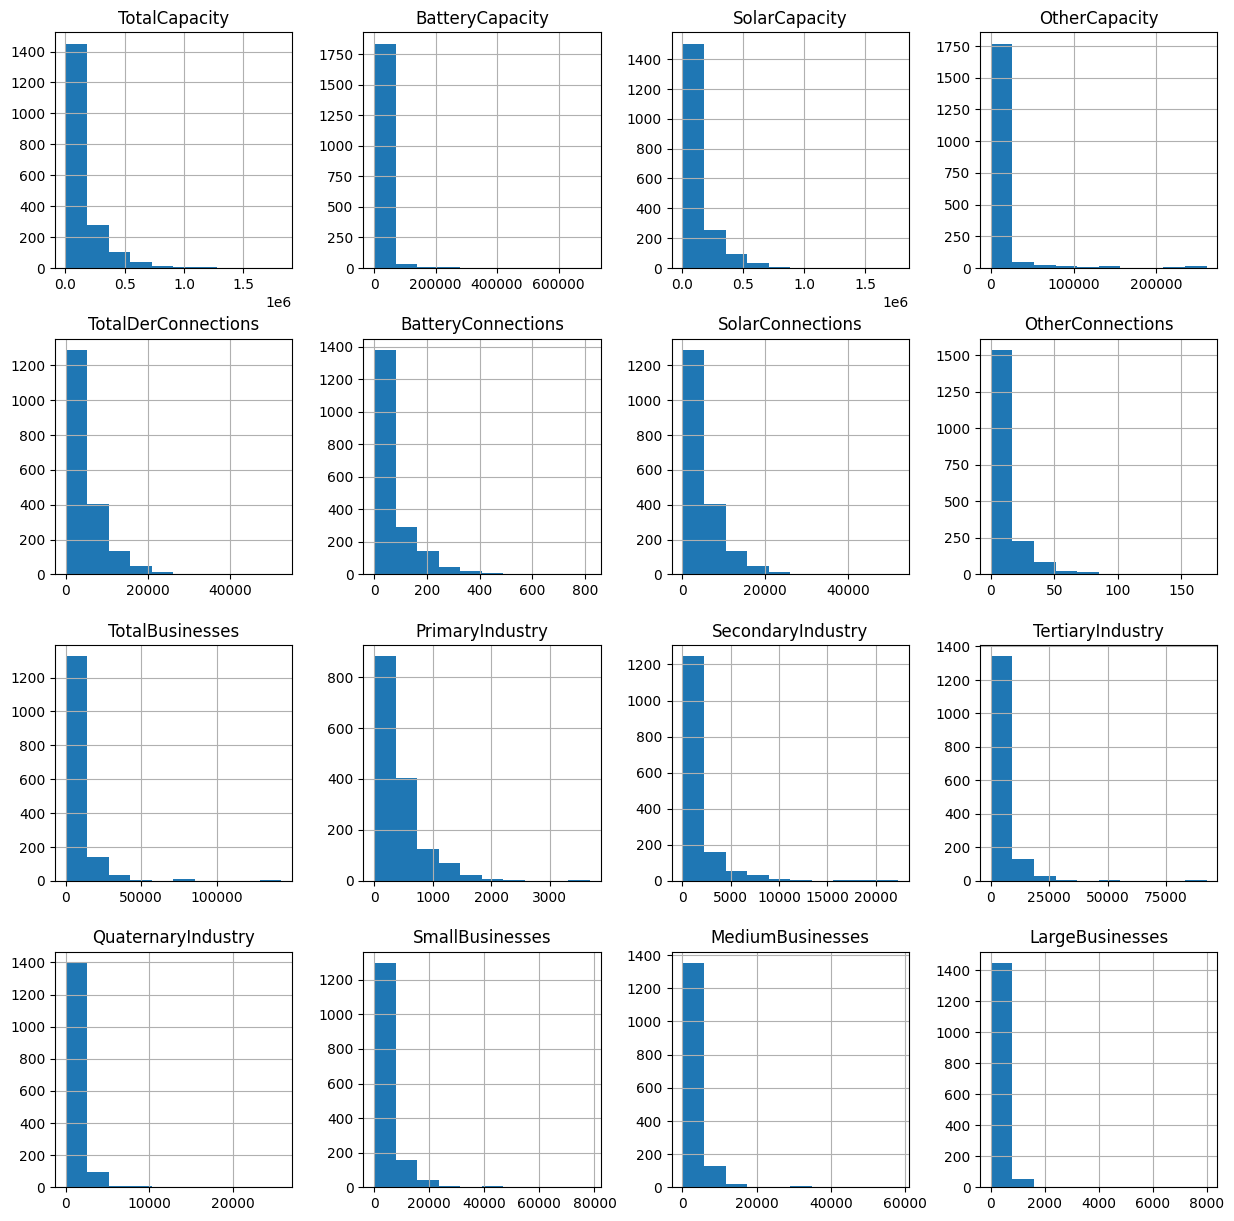

In [276]:
# Plot histogram of business dataset
_ = bus_df.drop(['Lga','Year'],axis=1).hist(figsize=(15,15))
plt.show()

### Correlation

The correlation between the variables calculated below. Since several of the variables are skewed we will apply a log transformation to the data before calculating correlation.

In [277]:
### --- Define function used to plot correlation heatmap--- #

def plot_corr(dataframe: pd.DataFrame, target: str, transform_list:list):
    # Apply boxcox transformation on skewed columns
    
    df = dataframe.copy()
    
    for col in transform_list:
        df.loc[:,col] = np.log(df[col])

    # Correlation heatmap
    corr_data = df.copy()
    corr_matrix = corr_data[corr_data.columns[2:]].corr()
    
    # Plot heatmap 
    fig, ax = plt.subplots(1, figsize= (10,8))
    sns.heatmap(corr_matrix,annot=True,cmap=sns.color_palette("crest", as_cmap=True),ax = ax)
    plt.tight_layout()
    
    return fig, ax
    


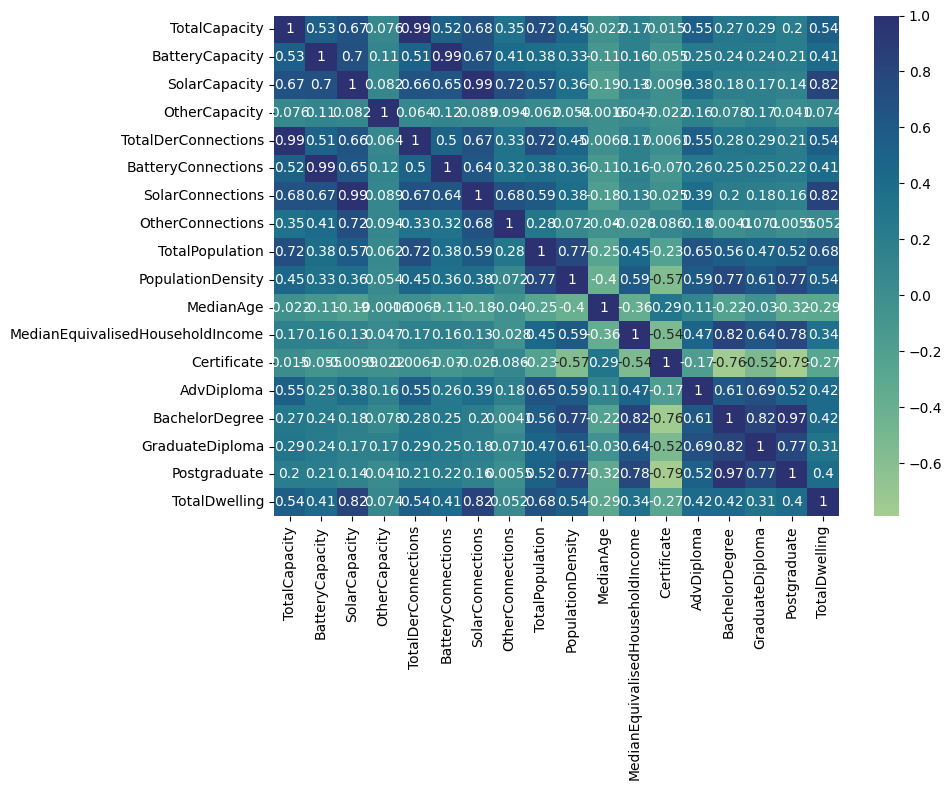

In [278]:
# --- Plot correlation heatmap for residential data --- #

target = 'TotalCapacity'
normalise_cols = ['TotalCapacity',
                  'TotalDerConnections',
                  'TotalPopulation',
                  'PopulationDensity'
                  ]

fig, ax = plot_corr(res_df,target,normalise_cols)

We observe:
- very high correlation between total capacity, battery capacity, total connections and solar connections (>0.9). In fact, solar capacity dominates total capacity. 
- high correlation of total capacity with LGA population. We see the not too surprising effect of the size of LGA driving total DER capacity.

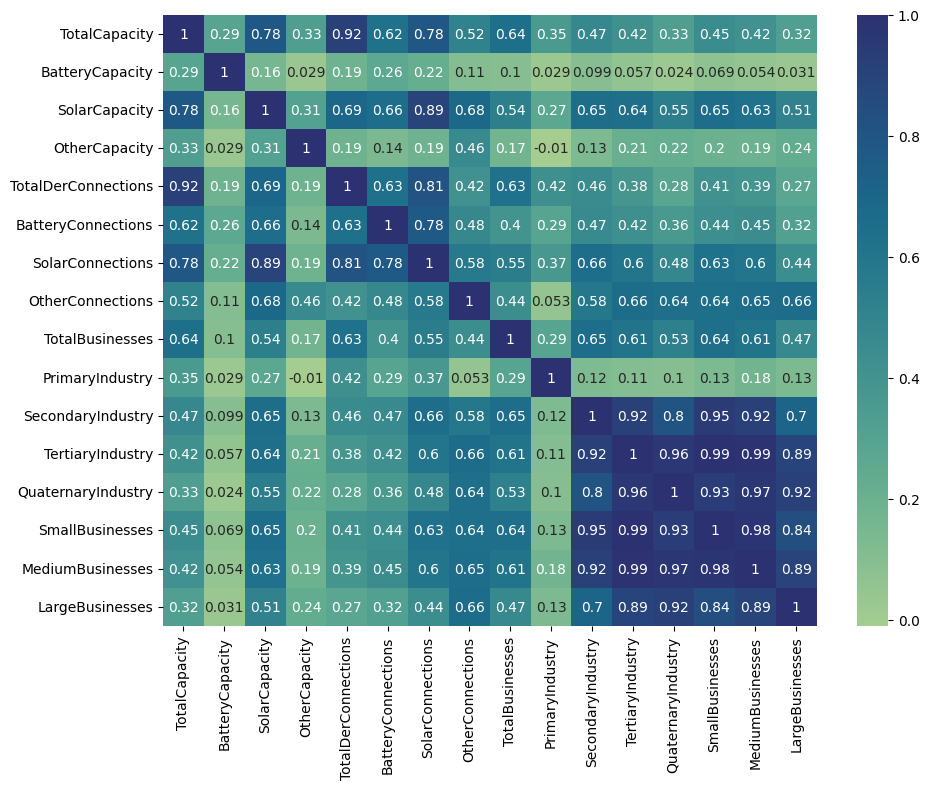

In [ ]:
# --- Plot correlation heatmap for business data --- #

target = 'TotalCapacity'
normalise_cols = [
    'TotalCapacity',
    'TotalDerConnections',
    'TotalBusinesses'
    ]

fig, ax = plot_corr(bus_df,target,normalise_cols)

We observe:
- Very high correlation between total capacity and solar capacity (>0.9). 
- Moderate correlation of total capacity with small and medium businesses and secondary and tertiary industries. May indicate a metropolitan vs rural divide. 


## Data Processing 


DER Fact Table: 
- Dropped 'None' and 'Blank' entries in 'Type' column in DERR data. 
- Remove misaligned LGAs and recorded their codes in SQL table.
- Filter out 2025 since year is incomplete. 

Population and Economic Fact Tables: 
- Forwardfill followed by backfill population data. With the exception of the first year, each year corresponds to data from the last reported census. 
- Processed mismatches in total number of businesses and sum of business sectors. If discrepancy is less than 5% of total business number, fill NAs with 0. For the remaining rows, drop LGA. 

In [280]:
# ---  Clean data --- #

derr_clean = derr_df.copy()
population_clean = population_df.copy()
economy_clean = economy_df.copy()

# Change '(blank)' rows to NaN
filter_blank = derr_clean['Type'] == '(blank)'
derr_clean.loc[filter_blank,['Type']] = None

# Change 'NoClassification' to NaN
filter_noclass = derr_clean['Type'] == 'NoClassification'
problem_lga = list(set((derr_clean.loc[filter_noclass,['Lga']].values).flatten()))
derr_clean.loc[filter_noclass,['Type']] = None

# Drop NaNs from type
derr_clean.dropna(subset = ['Type'], inplace=True)

# Drop Nans in LGA (due to aggregate at state level)
derr_clean.dropna(subset = ['Lga'], inplace=True)

# Ad dwelling data to population data
population_clean = population_clean.merge(
    right=dwelling_df,
    how='left',
    on=['Lga','Year']
    )

# Forward fill then backfill to impute missing values in population data 
population_clean.sort_values(
    by=['Lga','Year'],
    inplace=True
    )

cols = list(population_clean.columns)
cols.remove('Lga')

population_clean[cols] = (
    population_clean.groupby('Lga')
    .ffill()
    .bfill()
    )

# Remove 2025 year 
filter_2025 = derr_clean['Year']==2025 # Socioeconomic data does not cover 2025

res_filter = derr_clean['Type']=='RESIDENTIAL'
bus_filter = derr_clean['Type']=='BUSINESS'


In [281]:
population_clean

,Lga,Year,TotalPopulation,PopulationDensity,MedianAge,MedianEquivalisedHouseholdIncome,Certificate,AdvDiploma,BachelorDegree,GraduateDiploma,Postgraduate,TotalDwelling
0,10050,2020,55466.0,181.5,38.5,947.0,24.0,9.2,13.1,2.4,3.7,24118.0
1,10050,2021,56067.0,183.4,39.1,947.0,24.0,9.2,13.1,2.4,3.7,24118.0
2,10050,2022,56665.0,185.4,39.2,947.0,24.0,9.2,13.1,2.4,3.7,24118.0
3,10050,2023,57509.0,188.2,39.3,947.0,24.0,9.2,13.1,2.4,3.7,24118.0
4,10050,2024,58317.0,190.8,39.3,947.0,24.0,9.2,13.1,2.4,3.7,24118.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2730,99399,2020,2437.0,23.0,48.8,852.0,23.2,9.3,11.0,1.6,3.2,1179.0
2731,99399,2021,2530.0,23.9,49.3,852.0,23.2,9.3,11.0,1.6,3.2,1179.0
2732,99399,2022,2518.0,23.8,49.9,852.0,23.2,9.3,11.0,1.6,3.2,1179.0
2733,99399,2023,2511.0,23.7,50.8,852.0,23.2,9.3,11.0,1.6,3.2,1179.0


In [282]:
# --- Create separate residential and business data  --- #

# Create residential data 

res_df = derr_clean.loc[~filter_2025 & res_filter,:].copy()

res_df = res_df.merge(
    right = population_clean,
    how='left',
    on=['Lga','Year']
    )

# Create business data 

bus_df = derr_clean.loc[~filter_2025 & bus_filter,:].copy()

bus_df = bus_df.merge(
    right = economy_clean,
    how = 'left',
    on=['Lga','Year']
)           

# Aggregate by year
agg_res_df = res_df.groupby(['Lga']).mean(numeric_only=True).drop('Year',axis=1).reset_index()
agg_bus_df = bus_df.groupby(['Lga']).mean(numeric_only=True).drop('Year',axis=1).reset_index()


## Feature Selection

In this section we create KPIs and metrics that measures solar and battery adoption in each LGA by year.

For residential data, we derive 
- Penetration rate: connections per dwelling.
- Capacity per dwelling.
- Annual adoption rate: coefficient of year in linear regression model predicting capacity. 
- Quality: Capacity per connection.
- BSR: battery connections to solar connections ratio.

For business data, we derive the same KPIs as the above but replace capacity per dwelling with capacity per number of businesses. 


In [283]:
from sklearn.linear_model import LinearRegression

def cal_growth(df: pd.DataFrame, var: str) -> pd.Series:
    growth = {}
    # Calculate growth for each LGA
    for lga, group in df.groupby("Lga"):
        X = (group["Year"] - group["Year"].min()).values.reshape(-1, 1)
        y = group[var].values
        model = LinearRegression().fit(X, y)
        
        growth[lga] = model.coef_[0]
    return df["Lga"].map(growth)


def divider(x,y):
    """Handles cases where x[i] = y[i] = 0. Retains NA if x[i] != y[i]=0"""
    zero_exception = [i+j != 0 for i,j in zip(x,y)]
    return np.divide(x, y, out=np.zeros_like(x), where=zero_exception)

In [284]:
x=[0,1,2]
y=[0,0,2]

[i+j != 0 for i,j in zip(x,y)]


[False, True, True]

In [285]:
# Create KPIs for Residential Dataset 

res_metrics = pd.DataFrame(
    data=res_df[['Year','Lga']]
)

technologies = {
    'Total':   {'cap': 'TotalCapacity',   'con': 'TotalDerConnections'},
    'Battery': {'cap': 'BatteryCapacity', 'con': 'BatteryConnections'},
    'Solar':   {'cap': 'SolarCapacity',   'con': 'SolarConnections'},
    'Other':   {'cap': 'OtherCapacity',   'con': 'OtherConnections'},
}

for label, cols in technologies.items():
    cap, con = cols['cap'], cols['con']
    res_metrics[f'Pen{label}'] = divider(res_df[con],res_df['TotalDwelling'])
    res_metrics[f'CPD{label}'] = divider(res_df[cap], res_df['TotalDwelling'])
    res_metrics[f'CPC{label}'] = divider(res_df[cap], res_df[con])
    res_metrics[f'Growth{label}'] = cal_growth(res_df, cap)

# BESS attachment rate
res_metrics['BSR'] = divider(res_df['BatteryConnections'], res_df['SolarConnections'])

# Check NAs 
res_metrics.isna().sum()


Year             0
Lga              0
PenTotal         0
CPDTotal         0
CPCTotal         0
GrowthTotal      0
PenBattery       0
CPDBattery       0
CPCBattery       0
GrowthBattery    0
PenSolar         0
CPDSolar         0
CPCSolar         0
GrowthSolar      0
PenOther         0
CPDOther         0
CPCOther         0
GrowthOther      0
BSR              0
dtype: int64

In [286]:
# Create KPIs for Business Dataset 

bus_metrics = pd.DataFrame(
    data=res_df[['Year','Lga']]
)

technologies = {
    'Total':   {'cap': 'TotalCapacity',   'con': 'TotalDerConnections'},
    'Battery': {'cap': 'BatteryCapacity', 'con': 'BatteryConnections'},
    'Solar':   {'cap': 'SolarCapacity',   'con': 'SolarConnections'},
    'Other':   {'cap': 'OtherCapacity',   'con': 'OtherConnections'},
}

for label, cols in technologies.items():
    cap, con = cols['cap'], cols['con']
    bus_metrics[f'Pen{label}'] = divider(bus_df[con], bus_df['TotalBusinesses'])
    bus_metrics[f'CPD{label}'] = divider(bus_df[cap],bus_df['TotalBusinesses'])
    bus_metrics[f'CPC{label}'] = divider(bus_df[cap], bus_df[con]) 
    bus_metrics[f'Growth{label}'] = cal_growth(bus_df, cap)

# BESS attachment rate
bus_metrics['BSR'] = divider(bus_df['BatteryConnections'],bus_df['SolarConnections'])

# Check NAs
bus_metrics.isna().sum()


Year             0
Lga              0
PenTotal         4
CPDTotal         4
CPCTotal         4
GrowthTotal      4
PenBattery       4
CPDBattery       4
CPCBattery       4
GrowthBattery    4
PenSolar         4
CPDSolar         4
CPCSolar         4
GrowthSolar      4
PenOther         4
CPDOther         4
CPCOther         4
GrowthOther      4
BSR              4
dtype: int64

In [287]:
bus_df[bus_df['Lga']==99399.0]

,Year,Lga,Type,TotalCapacity,BatteryCapacity,SolarCapacity,OtherCapacity,TotalDerConnections,BatteryConnections,SolarConnections,OtherConnections,TotalBusinesses,PrimaryIndustry,SecondaryIndustry,TertiaryIndustry,QuaternaryIndustry,SmallBusinesses,MediumBusinesses,LargeBusinesses
1512,2021,99399.0,BUSINESS,4231.40,0.0,4231.40,0.0,450.0,0.0,450.0,0.0,48.0,0.0,6.0,36.0,11.0,36.0,13.0,0.0
1513,2022,99399.0,BUSINESS,4511.00,0.0,4511.00,0.0,466.0,0.0,466.0,0.0,57.0,3.0,9.0,28.0,15.0,41.0,19.0,0.0
1514,2023,99399.0,BUSINESS,4839.40,0.0,4839.40,0.0,492.0,0.0,492.0,0.0,63.0,6.0,10.0,43.0,12.0,45.0,18.0,0.0
1515,2024,99399.0,BUSINESS,5220.76,0.0,5220.76,0.0,526.0,0.0,526.0,0.0,68.0,3.0,6.0,37.0,17.0,52.0,19.0,3.0


In [288]:

# ---  Save Processed Data --- #
processed_path = "../data/processed"

# Save Business and Residential Data
res_df.to_parquet(processed_path+"/res_data.parquet")
bus_df.to_parquet(processed_path+"/bus_data.parquet")

# Save Metrics Data
res_metrics.to_parquet(processed_path+"/resmetrics_data.parquet")
bus_metrics.to_parquet(processed_path+"/busmetrics_data.parquet")

In [289]:
# --- CSV save Temp --- #

# Save Business and Residential Data
res_df.to_csv(processed_path+"/res_data.csv")
bus_df.to_csv(processed_path+"/bus_data.csv")

# Save Metrics Data
res_metrics.to_csv(processed_path+"/resmetrics_data.csv")
bus_metrics.to_csv(processed_path+"/busmetrics_data.csv")